<a href="https://colab.research.google.com/github/edupro2000/-afiffel-Going-Deeper/blob/main/KOSSA_%EB%84%A4%EC%9D%B4%EB%B2%84%EB%89%B4%EC%8A%A4_API_%EC%8B%9C%EC%9E%A5%EC%A1%B0%EC%82%AC_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 데이터 정제 및 준비

- 네이버 API( [네이버 개발자 센터](https://)https://developers.naver.com/docs/serviceapi/search/news/news.md#%EB%89%B4%EC%8A%A4)에서 API 활용법, 샘플코드등 확인하고 진행해 보세요.
- 챗GPT를 활용하여 코드 입력하고 각 코드를 해석해 보세요.
- 챗GPT를 활용하여 데이터 중복제거 및 결측치 코드 수정을 진행해 보세요.


###### <보조설명> - JSON은 사람과 기계 모두가 읽을 수 있는 오픈 데이터 교환 형식입니다. JSON은 모든 프로그래밍 언어에 독립적이며 매우 다양한 애플리케이션의 일반적인 API 출력입니다.<BR> - XML은 데이터를 정의하는 규칙을 제공하는 마크업 언어로, 태그를 사용하여 데이터 속성과 실제 데이터를 구분합니다. <출처: AWS> <BR> - 차이점 : <a href="https://aws.amazon.com/ko/compare/the-difference-between-json-xml" target="_balnk"> JSON VS XML 차이</a>

### 1) 라이브러리 설치

In [ ]:
# 네이버 검색 API 예제 - (출처 : 네이버 디벨로퍼)
import os
import sys
import urllib.request
import pandas as pd
import json
import re #제목, 요약에서 tag 제거

### 2) 네이버 API의 ID 및 SECRET 입력
- 네이버 Developers >Products>서비스API>[데이터랩 바로가기](https://developers.naver.com/products/service-api/datalab/datalab.md)
- 비로그인 오픈 API 서비스 환경에  http://localhost  을 입력해 주세요

In [ ]:
#네이버 API ID를 입력해 주세요
client_id = "Jwrla***************"
#네이버 API SECRET를 입력해 주세요
client_secret = "Sgr3*************"

### 3) 검색할 키워드 리스트 작성

챗GPT 프롬프트를 입력하며 코드를 수정해 보세요.


- 2024년 군 사이버 보안의 이슈 및 트렌드 분석을 하고 싶어. 뉴스에서 크롤링을 위한 키워드 10개만 추천해줘.
- #임무 : 추천 받은 10개의 리스트를 "군사정보 해킹", 의  형태로 정리해

-  "군 사이버사령부", "국방 AI 보안", "군사정보 해킹", "사이버전 대응", "국방 클라우드 보안", "군 랜섬웨어 대응", "국방 IoT 보안", "군 사이버 인력 양성", "국방 암호화 기술", "군 사이버 훈련"

In [ ]:
import pandas as pd
import urllib.request
import json
import re

# 검색할 '00시장 트렌드 키워드'
keywords = [ "군 사이버사령부", "국방 AI 보안", "군사정보 해킹", "사이버전 대응", "국방 클라우드 보안", "군 랜섬웨어 대응", "국방 IoT 보안", "군 사이버 인력 양성", "국방 암호화 기술", "군 사이버 훈련"]

display = 100  # 한 번의 요청으로 가져올 수 있는 최대 기사 수
start = 1
end = 1001  # 총 요청 횟수 display가 100개 일때 10번 요청시 1000개

web_df = pd.DataFrame(columns=("키워드", "제목", "요약", "게시일", "링크"))

# idx 초기화 위치 변경 - 각 키워드별로 인덱스 초기화가 아닌, 전체 프로세스 시작 시에만 초기화
idx = 0

for keyword in keywords:
    encText = urllib.parse.quote(keyword)

    for start_index in range(start, end, display):
        url = "https://openapi.naver.com/v1/search/news?query=" + encText \
              + "&display=" + str(display) \
              + "&start=" + str(start_index)

        request = urllib.request.Request(url)
        request.add_header("X-Naver-Client-Id", client_id)
        request.add_header("X-Naver-Client-Secret", client_secret)
        response = urllib.request.urlopen(request)
        rescode = response.getcode()

        if rescode == 200:
            response_body = response.read()
            response_dict = json.loads(response_body.decode('utf-8'))
            items = response_dict['items']
            for item_index in range(len(items)):
                remove_tag = re.compile('<.*?>')
                title = re.sub(remove_tag, '', items[item_index]['title'])
                description = re.sub(remove_tag, '', items[item_index]['description'])
                pubDate = items[item_index]['pubDate']
                link = items[item_index]['link']
                web_df.loc[idx] = [keyword, title, description, pubDate, link]
                idx += 1  # 인덱스 증가는 내부 반복문에서 계속 이루어짐
        else:
            print("Error Code:" + rescode)

# 결과 데이터프레임 출력
print(web_df)

           키워드                                                 제목  \
0     군 사이버사령부  대통령 국정브리핑 전문)&quot;저는 쉬운 길을 가지 않겠습니다. '4대 개혁' ...   
1     군 사이버사령부     김용현 국방장관 후보자 &quot;장병 복무 여건·처우 획기적 개선하겠다&quot;   
2     군 사이버사령부            [오늘과내일] &lt;1&gt; 대전 방위산업, 어떤 색으로 물들일까?   
3     군 사이버사령부             대통령실, 이재명 ‘계엄령 주장’에 “정말 말도 안 되는 정치 공세”   
4     군 사이버사령부                                   금감원·수방사 금융교육 MOU   
...        ...                                                ...   
9995  군 사이버 훈련     [전문] 한-우즈벡 공동성명 채택…&quot;K실크로드 이행 긴밀히 협력&quot;   
9996  군 사이버 훈련                 韓-우즈벡 정상회담 … KTX 수출·핵심광물 공급망 강화 성과   
9997  군 사이버 훈련    [전문] 한-우즈벡 공동성명...&quot;고속철·에너지 인프라·핵심광물 공급망...   
9998  군 사이버 훈련           한국 고속철, 우즈벡 첫 수출…尹 &quot;인프라 협력 확대&quot;   
9999  군 사이버 훈련  [전문] 尹, 우즈벡 정상회담...&quot;텅스텐 등 핵심광물 공급망 협력 약정 ...   

                                                     요약  \
0     한미동맹은 안보, 경제, 첨단기술, 정보, 사이버 분야를 망라한 포괄적인 협력 플랫...   
1     구축하겠다&quot;면서 &quot;우주·사이버·전자기 등 신영역 작전수행체계도 발.

In [ ]:
# 데이터를 엑셀 파일로 저장합니다.
filename = "네이버_뉴스_요약_중복제거_전.xlsx"
web_df.to_excel(filename, index=False, engine='openpyxl')

print(f"{filename}에 데이터를 저장했습니다.")
print("현재 작업 디렉토리:", os.getcwd())

네이버_뉴스_요약_중복제거_전.xlsx에 데이터를 저장했습니다.
현재 작업 디렉토리: /content


### 4) 데이터 정제(중복제거, 결측치 제거)

(1) 챗GPT 프롬프트를 입력하며 코드를 수정해 보세요.

- 제목과 요약을 봤을 때 중복기사가 너무 많은것 같아. 중복 기사를 삭제해줘
- 요약의 텍스트 10자가 다른 행과 동일한 경우에 중복된 행을 삭제 하고 싶은 경우 코드를 작성해죠
- 결측치가 있는지 확인하고 있는 경우 삭제 해죠

(2) 원본 대비 중복, 결측치가 얼마나 제거 되었는지 확인해 보세요.

In [ ]:
import pandas as pd
import re

# 데이터 파일 읽기
file_name = '/content/네이버_뉴스_요약_중복제거_전.xlsx'  # 실제 파일 경로로 변경
df = pd.read_excel(file_name)

# 원본 데이터의 행 수
original_count = len(df)

# 요약 텍스트에서 처음 15자를 추출하여 새로운 열 생성
df['summary_first_15'] = df['요약'].apply(lambda x: x[:15] if isinstance(x, str) else '')

# 'summary_first_15' 열을 기준으로 중복된 값을 제거
df.drop_duplicates(subset='summary_first_15', inplace=True)

# 중복 제거 후 데이터의 행 수
filtered_count = len(df)

# 중복 제거된 행 수 계산
removed_count = original_count - filtered_count

# 중복 제거 결과 출력
print(f"원본 데이터 수: {original_count}")
print(f"필터링 후 데이터 수: {filtered_count}")
print(f"제거된 데이터 수: {removed_count}")

# 'summary_first_15' 열 제거 (더 이상 필요 없으므로)
df.drop('summary_first_15', axis=1, inplace=True)

# 결측치가 있는 행 제거
df.dropna(inplace=True)

# 결측치 삭제 후 데이터의 행 수
after_missing_data_removed = len(df)

# 결측치 제거된 행 수 계산
removed_missing_count = filtered_count - after_missing_data_removed

# 결측치 삭제 결과 출력
print(f"결측치 삭제 전 데이터 수: {filtered_count}")
print(f"결측치 삭제 후 데이터 수: {after_missing_data_removed}")
print(f"제거된 결측치 데이터 수: {removed_missing_count}")

원본 데이터 수: 10000
필터링 후 데이터 수: 7066
제거된 데이터 수: 2934
결측치 삭제 전 데이터 수: 7066
결측치 삭제 후 데이터 수: 7065
제거된 결측치 데이터 수: 1


In [ ]:
# 필요한 경우 openpyxl 설치
#!pip install openpyxl

# 파일 엎어쓰기 방지를 위해 파일네임에 오늘 날짜 적기
from datetime import datetime

# 현재 날짜와 시간을 "YYYYMMDD" 형식으로 포맷팅
current_date = datetime.now().strftime("%Y%m%d")

# 데이터를 엑셀 파일로 저장합니다.
file_name = f"NAVER_NewsClipping_{current_date}.xlsx"
web_df.to_excel(file_name, index=False)

print(f"파일 저장 완료: {file_name}")

print("현재 작업 디렉토리:", os.getcwd())

파일 저장 완료: NAVER_NewsClipping_20240904.xlsx
현재 작업 디렉토리: /content


# 2. 시장조사 분석하기
(1) 워드 클라우드로 각 키워드가 얼마나 자주 언급 되었는지 분석하여 가장 주목받는 주제를 확인해 보세요.
  - 제목에서 키워드 분석하기or 요약에서 키워드 분석하기

(2) 키워드 빈도수를 그래프로 살펴 보세요.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (28.0 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 123597 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/

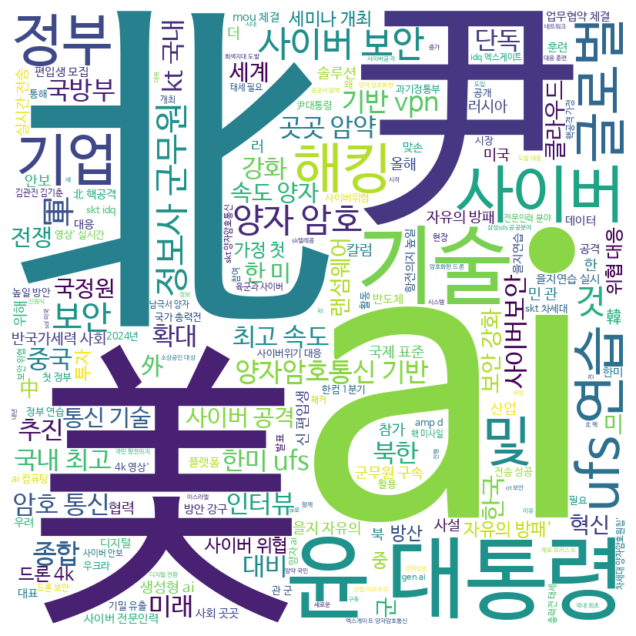

In [ ]:
# 한글 폰트 설치 및 캐시 삭제
# 주의: 한글 폰트를 설치 하지 않는 경우 폰트 깨짐이 일어 납니다.
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from datetime import datetime

# 현재 날짜를 yyyyMMdd 형식으로 포맷팅합니다.
current_date = datetime.now().strftime('%Y%m%d')

# 포맷팅된 날짜를 파일명에 적용합니다.pandas를 사용하여 엑셀 파일을 불러옵니다.
file_name = f'/content/NAVER_NewsClipping_{current_date}.xlsx'
df = pd.read_excel(file_name)

# matplotlib의 폰트를 Nanum 폰트로 설정 (모든 그래프에 대해 폰트 적용)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

# 모든 제목 텍스트를 하나의 문자열로 결합하고, 소문자로 변환
all_texts = " ".join(s.lower() for s in df['제목'])  # '제목' 열을 사용

# 기본 불용어 목록에 추가할 단어들
additional_stopwords = {'quot', '등', '지원', '漢字', '를', '이','는', '하다', '에','위한','지난해','경북도','개발','작년', '윤 대통령', '윤대통령'}  # 불용어 목록에 추가할 단어들

# 기본 불용어 목록에 추가
stopwords = set(STOPWORDS).union(additional_stopwords)

# 워드 클라우드 생성 (한글 폰트 지정, 불용어 목록 적용)
wordcloud = WordCloud(font_path='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
                      width=800, height=800,
                      background_color='white',
                      stopwords=stopwords).generate(all_texts)

# 워드 클라우드 시각화
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


다운 받았던 엑셀 파일의 '제목'항목에서 자주 사용된 단어의 빈도수 추출해 주세요.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

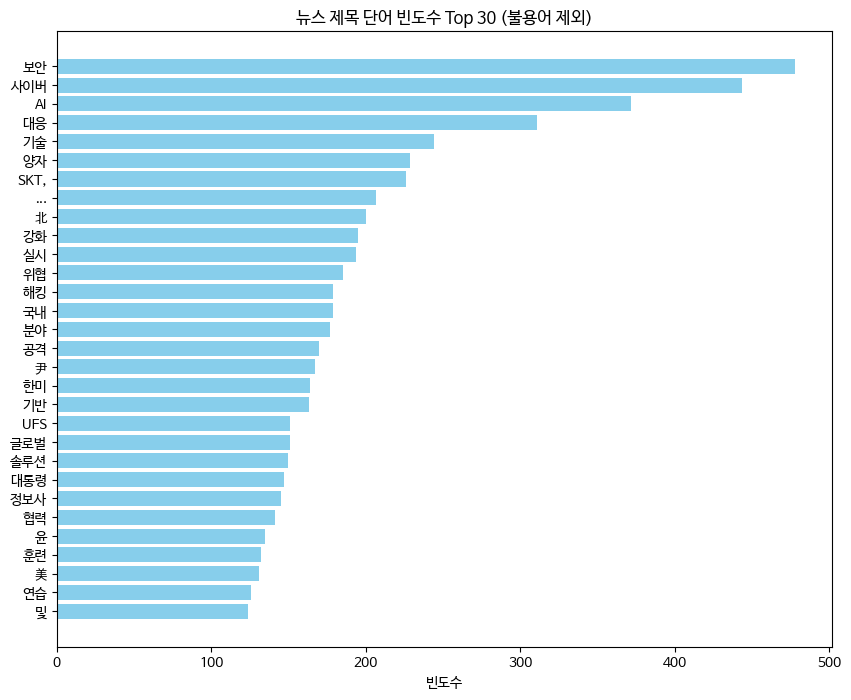

In [ ]:
# 한글 폰트 설치 및 캐시 삭제
# 주의: 한글 폰트를 설치 하지 않는 경우 폰트 깨짐이 일어 납니다.
# 한글 폰트가 깨진다면 상단카테고리의 런타임> 세션 다시 시작을 실행해 주세요.(ctrl+m)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

# 현재 날짜를 yyyyMMdd 형식으로 포맷팅합니다.
current_date = datetime.now().strftime('%Y%m%d')

# 파일 경로 설정하고 pandas를 사용하여 엑셀 파일을 불러옵니다.
file_path = f'/content/NAVER_NewsClipping_{current_date}.xlsx'
df = pd.read_excel(file_path)

# matplotlib의 폰트를 Nanum 폰트로 설정 (모든 그래프에 대해 폰트 적용)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 기본 불용어 목록에 추가할 단어들
additional_stopwords = {'quot', '등', '지원', '漢字', '를', '이','는', '하다', '에','획득','등급','사업','체결', '구축', '공급','개최','위한','출시','지난해','첫','확대','최대','전력','목표','리더십','경북도','개발','수상', '작년','시장','생산기지','실적','경영','추진'}  # 불용어 목록에 추가할 단어들

# '제목' 열의 모든 텍스트를 하나의 리스트로 결합하되, 불용어를 제외합니다.
words_list = ' '.join(df['제목']).split()
words_list = [word for word in words_list if word not in additional_stopwords]

# Counter 객체를 사용하여 단어의 빈도수를 계산합니다.
word_counts = Counter(words_list)

# 가장 흔한 30개 단어를 추출합니다.
most_common_words = word_counts.most_common(30)

# 단어와 빈도수를 분리하여 리스트로 만듭니다.
words = [word for word, freq in most_common_words]
frequencies = [freq for word, freq in most_common_words]

# 막대 그래프를 생성합니다.
plt.figure(figsize=(10, 8))
plt.barh(words, frequencies, color='skyblue')
plt.xlabel('빈도수')
plt.title('뉴스 제목 단어 빈도수 Top 30 (불용어 제외)')
plt.gca().invert_yaxis()  # 가장 높은 빈도수의 단어가 위로 오게 합니다.
plt.show()

In [ ]:
# 가장 흔한 30개 단어와 빈도수를 데이터프레임으로 변환합니다.
df_common_words = pd.DataFrame(most_common_words, columns=['단어', '빈도수'])

# 엑셀 파일로 저장합니다. 파일명은 'Top_30_Words_{current_date}.csv'로 설정합니다.
output_file_path = f'Top_30_Words_{current_date}.csv'
df_common_words.to_csv(output_file_path, index=False)

# 저장된 파일 경로를 출력합니다.
print(f'파일이 저장되었습니다: {output_file_path}')

파일이 저장되었습니다: Top_30_Words_20240904.csv


#3. 인사이트 도출

 - 생성형AI를 활용해 2024년 군 사이버 보안의 주요 이슈와 트렌드에 대한 시사점을 분석해보기

NAVER_NewsClipping_20240830 데이터를 활용


# 키워드간 상관관계 분석하기

분석 계획:
키워드 간의 상관 관계 분석: 각 기사에서 함께 등장하는 키워드를 기반으로 상관 관계를 계산합니다.
연관 분석: 키워드들 간의 연관 규칙을 도출하여 어떤 키워드들이 자주 함께 등장하는지 파악합니다.
이를 위해 먼저 키워드들의 상관 관계를 계산해보겠습니다.
키워드 간의 상관 관계 분석 결과, 상위 10개의 키워드 쌍은 다음과 같습니다:

국방 - 보안: 0.801
양성 - 사이버: 0.667
훈련 - 사이버: 0.667
사이버전 - 대응: 0.667
사이버 - 군: 0.612
IoT - 보안: 0.509
클라우드 - 보안: 0.509
보안 - AI: 0.509
군 - 사이버사령부: 0.408
훈련 - 군: 0.408


해석 및 시사점:
국방과 보안의 높은 상관 관계는 국방 분야에서 보안이 매우 중요한 요소로 다뤄지고 있음을 나타냅니다.
사이버와 관련된 키워드들 (예: 양성, 훈련, 군) 사이의 강한 상관 관계는 사이버 보안 훈련과 인력 양성이 현재 중요한 이슈임을 시사합니다.
AI와 보안의 상관 관계는 인공지능이 보안 분야에서 중요한 역할을 하고 있음을 보여줍니다.
클라우드, IoT와 보안 간의 연관성은 최신 기술 트렌드에서 보안이 중요한 고려사항임을 나타냅니다.

# 주어진 데이터를 기반으로 한 SWOT 분석을 진행해줘

이 분석은 사이버 보안, 국방, AI, 사이버전, 훈련, 클라우드, IoT 등과 관련된 주제들을 중심으로 한미동맹과 대한민국의 국방 및 보안 전략에 대한 시사점을 도출하는 데 초점을 맞추겠습니다.

1. Strengths (강점):
국방과 보안의 연계성: 높은 상관 관계를 보인 국방과 보안은 대한민국이 사이버 보안 및 국방을 강화하기 위한 체계적인 접근을 하고 있음을 나타냅니다. 이는 국가 안보를 포괄적으로 보호할 수 있는 강점으로 작용합니다.
AI와 보안 기술의 결합: AI와 보안의 상관 관계는 인공지능 기술을 활용하여 보안을 강화하는 능력이 뛰어나다는 것을 시사합니다. 이는 최신 기술을 국방 및 보안에 적용하는 데 있어 대한민국의 강점을 나타냅니다.
2. Weaknesses (약점):
사이버전 대비 미흡: 사이버전과 대응의 높은 상관 관계는 사이버 공격에 대한 대비가 중요한 이슈임을 나타내지만, 이와 동시에 이러한 위협에 대한 취약성을 시사할 수 있습니다. 사이버 보안 공격에 대한 대응 능력이 부족하거나, 사이버전에서의 방어력이 충분하지 않다면 이는 약점이 될 수 있습니다.
인력 양성 및 훈련 부족: 사이버와 훈련, 양성의 상관 관계는 사이버 보안 인력 양성과 훈련이 중요한 과제로 대두되고 있음을 나타냅니다. 충분한 전문 인력을 확보하지 못한다면, 이는 잠재적인 약점이 될 수 있습니다.
3. Opportunities (기회):
첨단 기술을 활용한 보안 강화: 클라우드, IoT와 보안 간의 연관성은 최신 기술을 활용한 보안 강화에 대한 기회를 제공합니다. 특히, 클라우드 및 IoT 기술을 적극적으로 활용하여 보안 전략을 강화할 수 있는 기회가 있습니다.
국제적 협력을 통한 사이버 보안 강화: 유엔사와의 협력 등 국제적 연대를 통해 사이버 보안을 강화하고, 글로벌 사이버 보안 전략을 공동으로 수립할 수 있는 기회가 존재합니다.
4. Threats (위협):
사이버전 위협 증가: 사이버전과 대응의 높은 상관 관계는 사이버전이 실제적인 위협으로 다가오고 있음을 시사합니다. 랜섬웨어, 해킹 등의 공격이 더욱 정교해지고 있으며, 이에 대응하지 못할 경우 심각한 위협이 될 수 있습니다.
기술의 빠른 발전 속도: AI, 클라우드, IoT 기술이 빠르게 발전함에 따라, 이러한 기술을 악용한 새로운 보안 위협이 증가할 수 있습니다. 이러한 위협에 대응하지 못한다면, 국가 안보에 심각한 영향을 미칠 수 있습니다.
종합적 시사점:
대한민국은 현재 사이버 보안과 국방을 강화하기 위해 AI 및 첨단 기술을 적극 활용하고 있으며, 이는 강력한 방어 능력을 구축하는 데 있어 중요한 강점이 됩니다. 그러나 사이버전 및 최신 기술로 인한 위협에 대비해야 하며, 이를 위해 인력 양성과 훈련을 지속적으로 강화할 필요가 있습니다. 또한, 국제적 협력과 첨단 기술의 적극적인 도입을 통해 이러한 위협을 기회로 전환할 수 있을 것입니다.

# 대한민국이 현재 사이버 보안과 국방을 강화하기 위해 AI 및 첨단 기술을 적극 활용하는 맥락에서 Deepfake 기술과 관련된 사례와 영상 합성 실습 교육의 효과에 대해 알려줘.

대한민국이 현재 사이버 보안과 국방을 강화하기 위해 AI 및 첨단 기술을 적극 활용하는 맥락에서 Deepfake 기술과 관련된 사례와 영상합성 실습 교육의 효과를 다음과 같이 정리할 수 있습니다.

1. Deepfake 사례와 사이버 보안에 대한 위협
국가 안보 위협: Deepfake 기술은 국가 안보에 심각한 위협을 가할 수 있습니다. 예를 들어, 정치 지도자나 군사 관계자의 얼굴과 목소리를 합성하여 가짜 명령을 전달하거나, 허위 정보를 퍼뜨려 혼란을 조성할 수 있습니다. 이러한 위협은 군사 작전이나 외교 관계에 악영향을 미칠 수 있습니다. 대한민국의 국방 및 사이버 보안 강화에 있어 이러한 Deepfake 위협을 미리 인지하고 대비하는 것은 매우 중요합니다.

심리전 및 정보전 활용: Deepfake 기술은 심리전(Information Warfare)에서 사용될 가능성이 큽니다. 적대 세력은 이를 통해 가짜 뉴스나 선전 영상을 제작해 국내외적으로 혼란을 야기할 수 있습니다. 대한민국이 이러한 기술적 위협에 대응하지 못하면, 사회적 불안과 정보 불신을 초래할 수 있습니다.

2. 영상합성 실습 교육의 효과
기술적 대응 능력 향상: 영상합성 실습 교육을 통해 국방 및 사이버 보안 전문가들이 Deepfake 기술의 원리와 한계를 직접 이해하고 다룰 수 있게 됩니다. 이는 잠재적인 위협을 조기에 감지하고 대응할 수 있는 능력을 배양하는 데 도움이 됩니다. 예를 들어, Deepfake 기술을 통해 만들어진 가짜 영상을 신속히 식별하고, 이에 맞서기 위한 기술적, 전략적 대응을 준비할 수 있습니다.

훈련 시나리오의 다양화: 영상합성 실습 교육은 군사 훈련 시나리오의 다양화에 기여할 수 있습니다. 예를 들어, Deepfake 기술을 활용한 가상 적의 공격 시나리오를 통해 군인들이 실제 상황에서 적의 심리전을 어떻게 대응할지 훈련할 수 있습니다. 이는 실전에서의 대응 능력을 향상시키고, 심리전 및 정보전에 대한 대비를 강화하는 데 효과적입니다.

디지털 리터러시 및 윤리적 감수성 강화: Deepfake 기술의 악용 가능성을 이해하고, 이에 대한 비판적 사고를 기르기 위해 영상합성 실습 교육이 필요합니다. 이를 통해 군 및 보안 관계자들은 단순히 기술적인 대응을 넘어서, 윤리적 고려를 바탕으로 기술을 책임감 있게 사용할 수 있는 능력을 배양할 수 있습니다.

국제적 협력 및 대응 전략 수립: 대한민국이 Deepfake 기술에 대한 이해를 높이면, 국제적 협력 네트워크에서 리더십을 발휘할 수 있습니다. 특히, 사이버 보안 분야에서 국제적인 협력을 통해 공동 대응 전략을 개발하고, Deepfake와 같은 첨단 기술을 악용하는 사이버 위협에 대한 글로벌 대응을 주도할 수 있습니다.

종합적 시사점
대한민국이 사이버 보안과 국방을 강화하기 위해 AI 및 첨단 기술을 적극 활용하는 상황에서, Deepfake 기술은 새로운 위협이자 도전 과제로 등장하고 있습니다. 영상합성 실습 교육은 이러한 위협에 대한 대응 능력을 강화하고, 디지털 리터러시를 향상시키며, 윤리적 감수성을 고취하는 데 중요한 역할을 할 수 있습니다. 이러한 교육을 통해 국방 및 보안 분야에서 Deepfake 기술을 효과적으로 이해하고, 그에 따른 위협을 미리 방지하는 전략을 수립할 수 있습니다.